<a href="https://colab.research.google.com/github/aakashkumar089/Class-notes/blob/main/OTS1_RandomForest_penguine_size.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix,classification_report,ConfusionMatrixDisplay,accuracy_score)

In [ ]:
df = pd.read_csv('/content/penguins_size.csv')

In [ ]:
df = df.dropna()

In [ ]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [ ]:
# Train Test Split

X = pd.get_dummies(df.drop('species',axis=1), drop_first=True)

In [ ]:
X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,True,True,False
4,36.7,19.3,193.0,3450.0,False,True,True,False
5,39.3,20.6,190.0,3650.0,False,True,False,True


In [ ]:
y = df['species']

In [ ]:
y.head()

,species
0,Adelie
1,Adelie
2,Adelie
4,Adelie
5,Adelie


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [ ]:
X_train.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
194,50.9,19.1,196.0,3550.0,True,False,False,True
22,35.9,19.2,189.0,3800.0,False,False,True,False
92,34.0,17.1,185.0,3400.0,True,False,True,False
149,37.8,18.1,193.0,3750.0,True,False,False,True
156,52.7,19.8,197.0,3725.0,True,False,False,True


In [ ]:
X_train.shape

(233, 8)

In [ ]:
model = RandomForestClassifier(n_estimators=10,max_features='sqrt',random_state=101)

In [ ]:
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=101)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array(['Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Chinstrap', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie', 'Chinstrap',
       'Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Chinstrap', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'A

In [ ]:
# Accuracy
print("Accuracy",accuracy_score(y_test,y_pred))

Accuracy 0.9702970297029703


In [ ]:
# COnfusion Matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[39  2  0]
 [ 1 22  0]
 [ 0  0 37]]


In [ ]:
# Classfication report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Adelie       0.97      0.95      0.96        41
   Chinstrap       0.92      0.96      0.94        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       101
   macro avg       0.96      0.97      0.97       101
weighted avg       0.97      0.97      0.97       101



In [ ]:
model.feature_importances_

array([0.31867744, 0.1018487 , 0.17343398, 0.21316964, 0.14512091,
       0.03720114, 0.00632264, 0.00422556])

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index= X_train.columns
)

print(importance.sort_values())

sex_MALE             0.004226
sex_FEMALE           0.006323
island_Torgersen     0.037201
culmen_depth_mm      0.101849
island_Dream         0.145121
flipper_length_mm    0.173434
body_mass_g          0.213170
culmen_length_mm     0.318677
dtype: float64


In [ ]:

test_error = []

for n in range(1,40):
    model = RandomForestClassifier(n_estimators=n,max_features='sqrt')
    model.fit(X_train,y_train)
    test_preds = model.predict(X_test)
    test_error.append(1 - accuracy_score(test_preds,y_test))

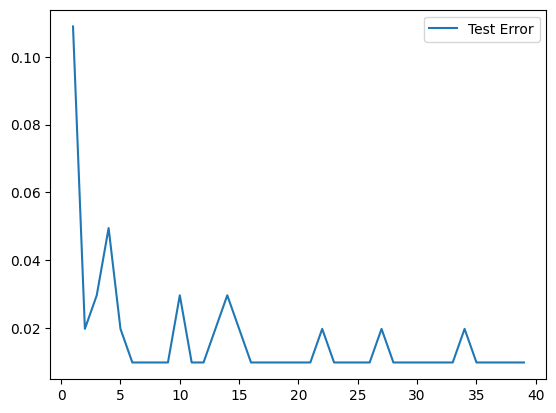

In [ ]:
plt.plot(range(1,40),test_error,label='Test Error')
plt.legend()

sex_MALE             0.004226
sex_FEMALE           0.006323
island_Torgersen     0.037201
culmen_depth_mm      0.101849
island_Dream         0.145121
flipper_length_mm    0.173434
body_mass_g          0.213170
culmen_length_mm

In [ ]:
# Now check prediction for new data


new_data = pd.DataFrame({
'island':['Torgersen'],
'sex':['MALE'],
'culmen_length_mm':[50],
'culmen_depth_mm':[17],
'body_mass_g':[3800],
'flipper_length_mm':[120]
})

In [ ]:
new_data

,island,sex,culmen_length_mm,culmen_depth_mm,body_mass_g,flipper_length_mm
0,Torgersen,MALE,50,17,3800,120


In [ ]:
# X = pd.get_dummies(df.drop('species',axis=1), drop_first=True)
new_data = pd.get_dummies(new_data)

In [ ]:
new_data

,culmen_length_mm,culmen_depth_mm,body_mass_g,flipper_length_mm,island_Torgersen,sex_MALE
0,50,17,3800,120,True,True


In [ ]:
new_data = new_data.reindex(columns=X_train.columns,fill_value=0)

In [ ]:
new_data

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,50,17,120,3800,0,True,0,True


In [ ]:
prediction = model.predict(new_data)

print('prediction',prediction)

prediction ['Adelie']


In [ ]:
probability = model.predict_proba(new_data)

print('predict_prob',probability)

predict_prob [[0.84615385 0.07692308 0.07692308]]


In [ ]:
model.classes_

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)